In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

генерация синтетических аддитивных данных

In [2]:
np.random.seed(465370)

n = 600
p = 3

X = np.random.uniform(0, 1, size=(n, p))

def true_f(X):
    return (
        np.sin(2 * np.pi * X[:, 0])
        + 0.5 * (X[:, 1] - 0.5)**2
        + np.exp(-3 * X[:, 2])
    )

sigma = 0.1
y = true_f(X) + np.random.normal(0, sigma, size=n)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print(f"train: {X_train.shape[0]} объектов, test: {X_test.shape[0]} объектов")

train: 450 объектов, test: 150 объектов


базисные функции — полиномиальный базис для каждого признака отдельно

In [3]:
def poly_basis(x_col, M):
    """
    строим матрицу [t^1, t^2, ..., t^M] для одного признака
    константу (t^0) не включаем — она войдёт как общий свободный член
    """
    return np.column_stack([x_col**m for m in range(1, M + 1)])

def build_Z(X, M):
    """
    формируем блочную матрицу признаков аддитивной модели:
    z_i = [1, psi_1(x_i1), ..., psi_M(x_i1), psi_1(x_i2), ..., psi_M(x_ip)]
    """
    n = X.shape[0]
    blocks = [np.ones((n, 1))]  # свободный член beta_0
    for j in range(X.shape[1]):
        blocks.append(poly_basis(X[:, j], M))
    return np.hstack(blocks)

M_default = 7
Z_train = build_Z(X_train, M_default)
Z_test  = build_Z(X_test,  M_default)
print(f"размер матрицы Z: {Z_train.shape}  (объекты x (1 + p*M))")

размер матрицы Z: (450, 22)  (объекты x (1 + p*M))


обучение аддитивной модели — МНК / ridge-регрессия (Уравнения 4-5 из отчёта)

In [4]:
def fit_additive(X_tr, y_tr, M, lam=1e-4):
    """
    оцениваем параметры ridge-МНК: theta = (Z^T Z + lam*I)^{-1} Z^T y
    небольшой lam на всякий случай стабилизирует систему при большом M
    """
    Z = build_Z(X_tr, M)
    n_params = Z.shape[1]
    theta = np.linalg.solve(Z.T @ Z + lam * np.eye(n_params), Z.T @ y_tr)
    return theta

def predict_additive(X, theta, M):
    Z = build_Z(X, M)
    return Z @ theta

theta = fit_additive(X_train, y_train, M_default)
y_pred_train = predict_additive(X_train, theta, M_default)
y_pred_test  = predict_additive(X_test,  theta, M_default)

mse_tr = mean_squared_error(y_train, y_pred_train)
mse_te = mean_squared_error(y_test,  y_pred_test)
r2_te  = r2_score(y_test, y_pred_test)

print(f"аддитивная модель (M={M_default}):")
print(f"  MSE train = {mse_tr:.4f}")
print(f"  MSE test  = {mse_te:.4f}")
print(f"  RMSE test = {np.sqrt(mse_te):.4f}")
print(f"  R^2 test  = {r2_te:.4f}")

аддитивная модель (M=7):
  MSE train = 0.0093
  MSE test  = 0.0121
  RMSE test = 0.1101
  R^2 test  = 0.9785


центрирование компонент (Уравнение 6 из отчёта)

In [5]:
def center_components(X_tr, theta, M):
    """
    после обучения вычитаем из каждой g_j её среднее по обучающей выборке
    и добавляем эти средние к свободному члену beta_0
    возвращаем скорректированный theta_c
    """
    p = X_tr.shape[1]
    theta_c = theta.copy()
    beta0_correction = 0.0

    for j in range(p):
        # коэффициенты g_j: theta[1 + j*M : 1 + (j+1)*M]
        idx_start = 1 + j * M
        idx_end   = 1 + (j + 1) * M
        a_j = theta[idx_start:idx_end]

        # значения g_j на обучающей выборке
        Phi_j = poly_basis(X_tr[:, j], M)
        g_j_vals = Phi_j @ a_j

        c_j = np.mean(g_j_vals)
        beta0_correction += c_j

        # вычитаем среднее из коэффициентов нулевого порядка не получится напрямую,
        # но можно скорректировать свободный член, а g_j пересчитать при визуализации
        # здесь просто запоминаем суммарную поправку к beta_0

    theta_c[0] += beta0_correction
    return theta_c, beta0_correction

theta_c, corr = center_components(X_train, theta, M_default)
print(f"поправка к свободному члену beta_0: {corr:.4f}")
print(f"beta_0 до центрирования: {theta[0]:.4f}")
print(f"beta_0 после центрирования: {theta_c[0]:.4f}")

поправка к свободному члену beta_0: -0.7650
beta_0 до центрирования: 1.0290
beta_0 после центрирования: 0.2640


линейная модель для сравнения

In [6]:
lin = LinearRegression().fit(X_train, y_train)
y_lin_train = lin.predict(X_train)
y_lin_test  = lin.predict(X_test)

print("линейная модель:")
print(f"  MSE train = {mean_squared_error(y_train, y_lin_train):.4f}")
print(f"  MSE test  = {mean_squared_error(y_test, y_lin_test):.4f}")
print(f"  RMSE test = {np.sqrt(mean_squared_error(y_test, y_lin_test)):.4f}")
print(f"  R^2 test  = {r2_score(y_test, y_lin_test):.4f}")

линейная модель:
  MSE train = 0.2041
  MSE test  = 0.2064
  RMSE test = 0.4543
  R^2 test  = 0.6348


полная полиномиальная модель для сравнения

In [7]:
# полином степени 3 со всеми попарными взаимодействиями
poly = PolynomialFeatures(degree=3, include_bias=True)
X_poly_train = poly.fit_transform(X_train)
X_poly_test  = poly.transform(X_test)

# ridge, чтобы не переобучиться — признаков много
full_model = Ridge(alpha=0.01).fit(X_poly_train, y_train)
y_full_train = full_model.predict(X_poly_train)
y_full_test  = full_model.predict(X_poly_test)

print(f"полная полиномиальная модель (degree=3, {X_poly_train.shape[1]} параметров):")
print(f"  MSE train = {mean_squared_error(y_train, y_full_train):.4f}")
print(f"  MSE test  = {mean_squared_error(y_test, y_full_test):.4f}")
print(f"  RMSE test = {np.sqrt(mean_squared_error(y_test, y_full_test)):.4f}")
print(f"  R^2 test  = {r2_score(y_test, y_full_test):.4f}")

print(f"\nчисло параметров: линейная={p+1}, аддитивная={1+p*M_default}, полная={X_poly_train.shape[1]}")

полная полиномиальная модель (degree=3, 20 параметров):
  MSE train = 0.0200
  MSE test  = 0.0247
  RMSE test = 0.1571
  R^2 test  = 0.9563

число параметров: линейная=4, аддитивная=22, полная=20


влияние числа базисных функций M на ошибки

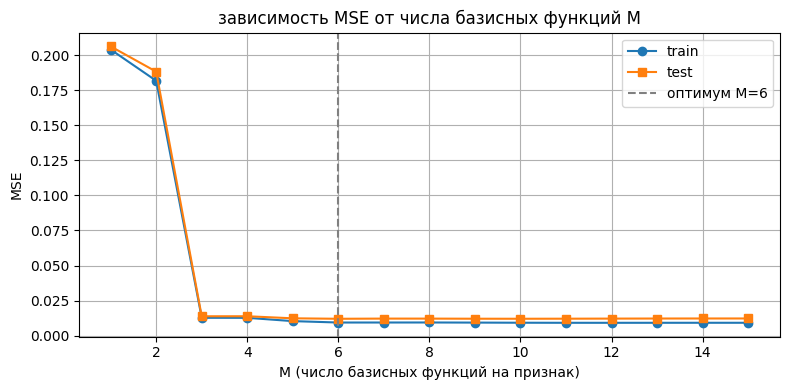

оптимальное M по тестовой ошибке: 6


In [8]:
M_values = list(range(1, 16))
mse_train_list = []
mse_test_list  = []

for M in M_values:
    th = fit_additive(X_train, y_train, M)
    y_tr_hat = predict_additive(X_train, th, M)
    y_te_hat = predict_additive(X_test,  th, M)
    mse_train_list.append(mean_squared_error(y_train, y_tr_hat))
    mse_test_list.append(mean_squared_error(y_test,  y_te_hat))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(M_values, mse_train_list, marker='o', label='train')
ax.plot(M_values, mse_test_list,  marker='s', label='test')
ax.axvline(M_values[np.argmin(mse_test_list)], color='gray', linestyle='--',
           label=f'оптимум M={M_values[np.argmin(mse_test_list)]}')
ax.set_xlabel('M (число базисных функций на признак)')
ax.set_ylabel('MSE')
ax.set_title('зависимость MSE от числа базисных функций M')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

best_M = M_values[np.argmin(mse_test_list)]
print(f"оптимальное M по тестовой ошибке: {best_M}")

восстановленные функции g_j — сравнение с истинными

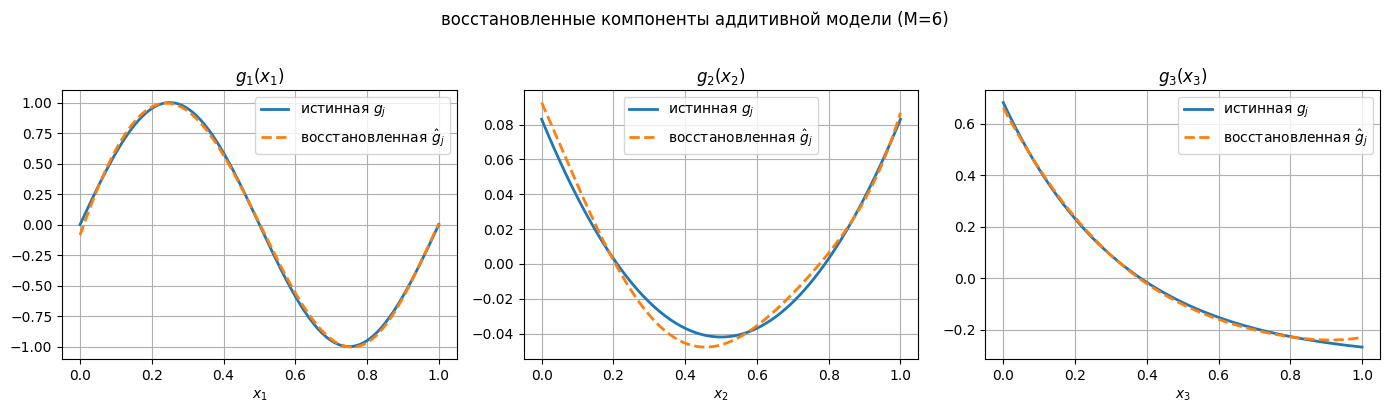

In [9]:
theta_best = fit_additive(X_train, y_train, best_M)

# истинные компоненты (до центрирования они определены с точностью до константы)
true_g = [
    lambda t: np.sin(2 * np.pi * t),
    lambda t: 0.5 * (t - 0.5)**2,
    lambda t: np.exp(-3 * t),
]

t_grid = np.linspace(0, 1, 300)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for j in range(p):
    ax = axes[j]
    idx_start = 1 + j * best_M
    idx_end   = 1 + (j + 1) * best_M
    a_j = theta_best[idx_start:idx_end]

    # значения восстановленной g_j на сетке
    Phi_grid = poly_basis(t_grid, best_M)
    g_hat = Phi_grid @ a_j

    # центрируем для сопоставления с истинной (истинные тоже центрируем)
    g_true = true_g[j](t_grid)
    g_hat_c  = g_hat  - np.mean(g_hat)
    g_true_c = g_true - np.mean(g_true)

    ax.plot(t_grid, g_true_c, label='истинная $g_j$', linewidth=2)
    ax.plot(t_grid, g_hat_c,  label='восстановленная $\\hat{g}_j$',
            linestyle='--', linewidth=2)
    ax.set_title(f'$g_{j+1}(x_{j+1})$')
    ax.set_xlabel(f'$x_{j+1}$')
    ax.legend()
    ax.grid(True)

plt.suptitle(f'восстановленные компоненты аддитивной модели (M={best_M})', y=1.02)
plt.tight_layout()
plt.show()

эксперимент на неаддитивных данных: y = sin(2pi*(x1+x2)) + 0.5*x3 + eps

In [10]:
def true_f_nonadd(X):
    return np.sin(2 * np.pi * (X[:, 0] + X[:, 1])) + 0.5 * X[:, 2]

y_na = true_f_nonadd(X) + np.random.normal(0, sigma, size=n)

X_tr_na, X_te_na, y_tr_na, y_te_na = train_test_split(X, y_na, test_size=0.25, random_state=42)

# аддитивная модель
th_na = fit_additive(X_tr_na, y_tr_na, best_M)
y_hat_add_na = predict_additive(X_te_na, th_na, best_M)

# полная полиномиальная модель
X_poly_tr_na = poly.fit_transform(X_tr_na)
X_poly_te_na = poly.transform(X_te_na)
full_na = Ridge(alpha=0.01).fit(X_poly_tr_na, y_tr_na)
y_hat_full_na = full_na.predict(X_poly_te_na)

print("неаддитивные данные:")
print(f"  аддитивная модель  — MSE test = {mean_squared_error(y_te_na, y_hat_add_na):.4f}, "
      f"R^2 = {r2_score(y_te_na, y_hat_add_na):.4f}")
print(f"  полная полиномиальная — MSE test = {mean_squared_error(y_te_na, y_hat_full_na):.4f}, "
      f"R^2 = {r2_score(y_te_na, y_hat_full_na):.4f}")

неаддитивные данные:
  аддитивная модель  — MSE test = 0.5442, R^2 = 0.0294
  полная полиномиальная — MSE test = 0.2377, R^2 = 0.5761


итоговая таблица сравнения всех моделей на аддитивных данных

In [11]:
results = {
    'линейная': {
        'MSE train': mean_squared_error(y_train, y_lin_train),
        'MSE test':  mean_squared_error(y_test,  y_lin_test),
        'RMSE test': np.sqrt(mean_squared_error(y_test, y_lin_test)),
        'R2 test':   r2_score(y_test, y_lin_test),
        'параметров': p + 1
    },
    f'аддитивная (M={best_M})': {
        'MSE train': mean_squared_error(y_train, predict_additive(X_train, theta_best, best_M)),
        'MSE test':  mse_test_list[best_M - 1],
        'RMSE test': np.sqrt(mse_test_list[best_M - 1]),
        'R2 test':   r2_score(y_test, predict_additive(X_test, theta_best, best_M)),
        'параметров': 1 + p * best_M
    },
    'полная полиномиальная': {
        'MSE train': mean_squared_error(y_train, y_full_train),
        'MSE test':  mean_squared_error(y_test,  y_full_test),
        'RMSE test': np.sqrt(mean_squared_error(y_test, y_full_test)),
        'R2 test':   r2_score(y_test, y_full_test),
        'параметров': X_poly_train.shape[1]
    }
}

print(f"{'модель':<30} {'MSE train':>10} {'MSE test':>10} {'RMSE test':>10} {'R2 test':>9} {'параметров':>11}")
print('-' * 85)
for name, m in results.items():
    print(f"{name:<30} {m['MSE train']:>10.4f} {m['MSE test']:>10.4f} "
          f"{m['RMSE test']:>10.4f} {m['R2 test']:>9.4f} {m['параметров']:>11}")

модель                          MSE train   MSE test  RMSE test   R2 test  параметров
-------------------------------------------------------------------------------------
линейная                           0.2041     0.2064     0.4543    0.6348           4
аддитивная (M=6)                   0.0093     0.0120     0.1096    0.9788          19
полная полиномиальная              0.0200     0.0247     0.1571    0.9563          20
